# **TikTok Project**
**Course 5 - The nuts and bolts of machine learning**

**Author:** Ahmad Daniel  
**Date:** May 2026

Recall that you are a data professional at TikTok. Your supervisor was impressed with the work you have done and has requested that you **build a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion**. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 5 End-of-course project: Classifying videos using machine learning**

In this activity, you will practice using machine learning techniques to predict on a binary outcome variable.

**The purpose** of this model is to mitigate misinformation in videos on the TikTok platform.

**The goal** of this model is to predict whether a TikTok video presents a "claim" or presents an "opinion".

*This activity has three parts:*

**Part 1:** Ethical considerations
* Consider the ethical implications of the request
* Should the objective of the model be adjusted?

**Part 2:** Feature engineering
* Perform feature selection, extraction, and transformation to prepare the data for modeling

**Part 3:** Modeling
* Build the models, evaluate them, and advise on next steps

# **Classify videos using machine learning**

## **PACE: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following questions:

1. **What are you being asked to do? What metric should I use to evaluate success of my business/organizational objective?**

2. **What are the ethical implications of the model? What are the consequences of your model making errors?**
   * What is the likely effect of the model when it predicts a false negative?
   * What is the likely effect of the model when it predicts a false positive?

3. **How would you proceed?**

**1. What are you being asked to do?**

**Business need and modeling objective**

TikTok users can report videos that they believe violate the platform's terms of service. Because there are millions of TikTok videos created and viewed every day, many videos get reported — too many to be individually reviewed by a human moderator.

Analysis indicates that when authors do violate the terms of service, they're much more likely to be presenting a claim than an opinion. Therefore, it is useful to be able to determine which videos make claims and which videos are opinions.

TikTok wants to build a machine learning model to help identify claims and opinions. Videos that are labeled opinions will be less likely to go on to be reviewed by a human moderator. Videos that are labeled as claims will be further sorted by a downstream process to determine whether they should get prioritized for review.

**Modeling design and target variable**

The data dictionary shows that there is a column called `claim_status`. This is a binary value that indicates whether a video is a claim or an opinion. This will be the target variable. This is a classification task because the model is predicting a binary class.

**Select an evaluation metric**

**2. What are the ethical implications of building the model?**

In the given scenario, it's better for the model to predict false positives when it makes a mistake, and worse for it to predict false negatives. It's very important to identify videos that break the terms of service, even if that means some opinion videos are misclassified as claims. The worst case for an opinion misclassified as a claim is that the video goes to human review. The worst case for a claim that's misclassified as an opinion is that the video does not get reviewed *and* it violates the terms of service.

Because it's more important to minimize false negatives, the model evaluation metric will be **recall**.

**3. How would you proceed?**

**Modeling workflow and model selection process**

Previous work with this data has revealed that there are ~20,000 videos in the sample. This is sufficient to conduct a rigorous model validation workflow, broken into the following steps:

1. Split the data into train/validation/test sets (60/20/20)
2. Fit models and tune hyperparameters on the training set
3. Perform final model selection on the validation set
4. Assess the champion model's performance on the test set

### **Task 1. Imports and data loading**

In [1]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.feature_extraction.text import CountVectorizer

# Import packages for data modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, \
recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

In [2]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

## **PACE: Analyze**

### **Task 2: Examine data, summary info, and descriptive stats**

In [3]:
# Display first few rows
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,8762575920,14,someone shared with me that an average human c...,not verified,under scrutiny,587292.0,53354.0,16958.0,812.0,234.0
1,2,claim,3611525817,59,someone shared with me that microbes from the ...,not verified,active,785464.0,156452.0,616.0,2878.0,1852.0
2,3,claim,5070975780,11,someone shared with me that 20% of the world's...,not verified,banned,999949.0,562158.0,35841.0,445.0,236.0
3,4,claim,7233352528,50,someone shared with me that the number of busi...,not verified,active,365084.0,49164.0,6122.0,372.0,25.0
4,5,claim,3387873230,55,someone shared with me that the total number o...,verified,active,672207.0,203409.0,57134.0,4253.0,1253.0


In [4]:
# Get number of rows and columns
data.shape

(19382, 12)

In [5]:
# Get basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19182 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19182 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19182 non-null  float64
 8   video_like_count          19182 non-null  float64
 9   video_share_count         19182 non-null  float64
 10  video_download_count      19182 non-null  float64
 11  video_comment_count       19182 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [6]:
# Generate basic descriptive stats
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19182.000000,19182.000000,19182.000000,19182.000000,19182.000000
mean,9691.500000,5.605640e+09,32.455061,253763.179856,83234.815243,16522.990929,1034.953498,341.892138
std,5595.245794,2.530172e+09,16.155484,320836.905107,131588.832099,31720.266661,1992.411530,776.994082
min,1.000000,1.234730e+09,5.000000,21.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.421425e+09,18.250000,4966.000000,836.250000,118.000000,7.000000,1.000000
50%,9691.500000,5.595368e+09,32.000000,9980.500000,3531.500000,742.000000,47.000000,10.000000
75%,14536.750000,7.798543e+09,46.000000,502163.000000,123078.000000,18042.000000,1141.750000,278.000000
max,19382.000000,9.999935e+09,60.000000,999976.000000,656081.000000,239681.000000,15278.000000,7887.000000


In [7]:
# Check for missing values
data.isna().sum()

#                             0
claim_status                200
video_id                      0
video_duration_sec            0
video_transcription_text    200
verified_status               0
author_ban_status             0
video_view_count            200
video_like_count            200
video_share_count           200
video_download_count        200
video_comment_count         200
dtype: int64

**Response:** There are very few missing values relative to the number of samples in the dataset. Therefore, observations with missing values can be dropped.

In [8]:
# Drop rows with missing values
data = data.dropna(axis=0)

In [9]:
# Check for duplicates
data.duplicated().sum()

np.int64(0)

**Response:** There are no duplicate observations in the data.

**Check for outliers:** Tree-based models are robust to outliers, so there is no need to impute or drop any values based on where they fall in their distribution.

In [10]:
# Check class balance
data["claim_status"].value_counts(normalize=True)

claim_status
claim      0.504118
opinion    0.495882
Name: proportion, dtype: float64

**Response:** Approximately 50.4% of the dataset represents claims and 49.6% represents opinions, so the outcome variable is balanced.

## **PACE: Construct**

### **Task 3. Feature engineering**

Extract the length (character count) of each `video_transcription_text` and add this to the dataframe as a new column called `text_length`.

In [11]:
# Create `text_length` column
data['text_length'] = data['video_transcription_text'].str.len()
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,8762575920,14,someone shared with me that an average human c...,not verified,under scrutiny,587292.0,53354.0,16958.0,812.0,234.0,122
1,2,claim,3611525817,59,someone shared with me that microbes from the ...,not verified,active,785464.0,156452.0,616.0,2878.0,1852.0,91
2,3,claim,5070975780,11,someone shared with me that 20% of the world's...,not verified,banned,999949.0,562158.0,35841.0,445.0,236.0,87
3,4,claim,7233352528,50,someone shared with me that the number of busi...,not verified,active,365084.0,49164.0,6122.0,372.0,25.0,128
4,5,claim,3387873230,55,someone shared with me that the total number o...,verified,active,672207.0,203409.0,57134.0,4253.0,1253.0,134


In [12]:
# Calculate average text_length for claims and opinions
data[['claim_status', 'text_length']].groupby('claim_status').mean()

,text_length
claim_status,
claim,95.513444
opinion,82.288057


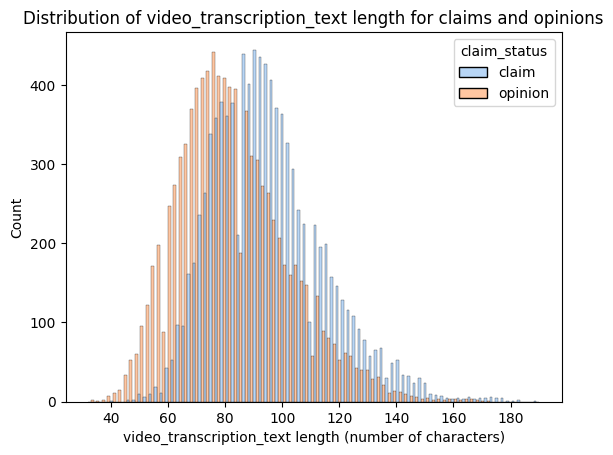

In [13]:
# Visualize the distribution of `text_length` for claims and opinions
sns.histplot(data=data, stat="count", multiple="dodge", x="text_length",
             kde=False, palette="pastel", hue="claim_status",
             element="bars", legend=True)
plt.xlabel("video_transcription_text length (number of characters)")
plt.ylabel("Count")
plt.title("Distribution of video_transcription_text length for claims and opinions")
plt.show()

Letter count distributions for both claims and opinions are approximately normal with a slight right skew. Claim videos tend to have more characters — about 13 more on average.

**Feature selection and transformation**

Encode target and categorical variables.

In [14]:
X = data.copy()
# Drop unnecessary columns
X = X.drop(['#', 'video_id'], axis=1)
# Encode target variable
X['claim_status'] = X['claim_status'].replace({'opinion': 0, 'claim': 1})
# Dummy encode remaining categorical values
X = pd.get_dummies(X,
                   columns=['verified_status', 'author_ban_status'],
                   drop_first=True)
X.head()

C:\Users\Daniel\AppData\Local\Temp\ipykernel_23148\16669879.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['claim_status'] = X['claim_status'].replace({'opinion': 0, 'claim': 1})


,claim_status,video_duration_sec,video_transcription_text,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under scrutiny
0,1,14,someone shared with me that an average human c...,587292.0,53354.0,16958.0,812.0,234.0,122,False,False,True
1,1,59,someone shared with me that microbes from the ...,785464.0,156452.0,616.0,2878.0,1852.0,91,False,False,False
2,1,11,someone shared with me that 20% of the world's...,999949.0,562158.0,35841.0,445.0,236.0,87,False,True,False
3,1,50,someone shared with me that the number of busi...,365084.0,49164.0,6122.0,372.0,25.0,128,False,False,False
4,1,55,someone shared with me that the total number o...,672207.0,203409.0,57134.0,4253.0,1253.0,134,True,False,False


### **Task 4. Split the data**

**Target variable:** `claim_status`
* 0 represents an opinion
* 1 represents a claim

In [15]:
# Isolate target variable
y = X['claim_status']

In [16]:
# Isolate features
X = X.drop(['claim_status'], axis=1)

# Display first few rows of features dataframe
X.head()

,video_duration_sec,video_transcription_text,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under scrutiny
0,14,someone shared with me that an average human c...,587292.0,53354.0,16958.0,812.0,234.0,122,False,False,True
1,59,someone shared with me that microbes from the ...,785464.0,156452.0,616.0,2878.0,1852.0,91,False,False,False
2,11,someone shared with me that 20% of the world's...,999949.0,562158.0,35841.0,445.0,236.0,87,False,True,False
3,50,someone shared with me that the number of busi...,365084.0,49164.0,6122.0,372.0,25.0,128,False,False,False
4,55,someone shared with me that the total number o...,672207.0,203409.0,57134.0,4253.0,1253.0,134,True,False,False


### **Task 5: Create train/validate/test sets**

Split data into training and testing sets, 80/20.

In [17]:
# Split the data into training and testing sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [18]:
# Split the training data into training and validation sets
# Result: 60/20/20 for train/validate/test
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=0)

In [19]:
# Get shape of each training, validation, and testing set
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((11508, 11), (3837, 11), (3837, 11), (11508,), (3837,), (3837,))

**Notes:**
- The number of features (11) aligns between the training, validation, and testing sets.
- The number of rows aligns between the features and outcome variable for training (~11,508) and both validation and testing (~3,837).

### **BONUS CONTENT — Tokenize text column**

The feature `video_transcription_text` is text-based. `CountVectorizer` converts it to numerical features by splitting text into n-grams (groups of n consecutive words) and tallying occurrences. This notebook uses 2-grams and 3-grams, keeping the 15 most frequently occurring tokens as features.

In [20]:
# Set up a CountVectorizer object
count_vec = CountVectorizer(ngram_range=(2, 3),
                            max_features=15,
                            stop_words='english')
count_vec

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(2, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [21]:
# Extract numerical features from video_transcription_text in training set
count_data = count_vec.fit_transform(X_train['video_transcription_text']).toarray()
count_data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(11508, 15))

In [22]:
# Place numerical representation into a dataframe
count_df = pd.DataFrame(data=count_data, columns=count_vec.get_feature_names_out())

# Display first few rows
count_df.head()

,colleague learned,colleague read,discussion board,friend learned,friend read,internet forum,learned media,learned news,media claim,news claim,point view,read discussion board,read media,read online,social media
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [23]:
# Concatenate X_train and count_df to form final training dataframe
X_train_final = pd.concat([X_train.drop(columns=['video_transcription_text']).reset_index(drop=True), count_df], axis=1)

# Display first few rows
X_train_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under scrutiny,...,internet forum,learned media,learned news,media claim,news claim,point view,read discussion board,read media,read online,social media
0,22,4444.0,918.0,245.0,21.0,7.0,85,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,29,7623.0,2916.0,122.0,71.0,11.0,61,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,29,584838.0,343563.0,87798.0,6022.0,2918.0,120,False,True,False,...,0,0,0,0,0,0,0,0,0,0
3,26,275070.0,17950.0,1045.0,387.0,128.0,94,False,False,False,...,1,0,0,0,0,0,0,0,0,0
4,58,6946.0,1578.0,256.0,24.0,3.0,60,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# Extract n-gram features for validation set (transform only, not fit)
validation_count_data = count_vec.transform(X_val['video_transcription_text']).toarray()
validation_count_df = pd.DataFrame(data=validation_count_data, columns=count_vec.get_feature_names_out())
X_val_final = pd.concat([X_val.drop(columns=['video_transcription_text']).reset_index(drop=True), validation_count_df], axis=1)

# Display first few rows
X_val_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under scrutiny,...,internet forum,learned media,learned news,media claim,news claim,point view,read discussion board,read media,read online,social media
0,15,8259.0,79.0,30.0,1.0,0.0,84,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,8,264.0,15.0,1.0,0.0,0.0,37,False,False,True,...,0,0,0,0,0,0,0,0,0,0
2,39,316110.0,191802.0,34727.0,4122.0,2211.0,76,False,False,True,...,0,1,0,0,0,0,0,0,0,0
3,59,219576.0,123402.0,1904.0,389.0,15.0,93,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,41,6110.0,182.0,60.0,2.0,0.0,94,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [25]:
# Extract n-gram features for test set (transform only, not fit)
test_count_data = count_vec.transform(X_test['video_transcription_text']).toarray()
test_count_df = pd.DataFrame(data=test_count_data, columns=count_vec.get_feature_names_out())
X_test_final = pd.concat([X_test.drop(columns=['video_transcription_text']).reset_index(drop=True), test_count_df], axis=1)
X_test_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under scrutiny,...,internet forum,learned media,learned news,media claim,news claim,point view,read discussion board,read media,read online,social media
0,28,5106.0,565.0,86.0,2.0,0.0,64,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,44,8333.0,231.0,26.0,5.0,1.0,69,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,7,560562.0,278994.0,71083.0,1318.0,249.0,113,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,60,919475.0,316889.0,90002.0,6596.0,812.0,62,False,False,True,...,0,0,0,1,0,0,0,1,0,0
4,52,31662.0,16542.0,711.0,313.0,70.0,147,False,False,False,...,0,0,0,0,0,0,0,0,0,0


### **Task 6. Build models**

### **Build a random forest model**

Fit a random forest model to the training set. Use cross-validation to tune the hyperparameters and select the model that performs best on recall.

In [26]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [5, 7, None],
             'max_features': [0.3, 0.6],
             'max_samples': [0.7],
             'min_samples_leaf': [1, 2],
             'min_samples_split': [2, 3],
             'n_estimators': [75, 100, 200],
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

In [27]:
%%time
rf_cv.fit(X_train_final, y_train)

CPU times: total: 2min 53s
Wall time: 2min 56s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 7, ...], 'max_features': [0.3, 0.6], 'max_samples': [0.7], 'min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [28]:
# Examine best recall score
rf_cv.best_score_

np.float64(0.995156905611398)

In [29]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': None,
 'max_features': 0.3,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 75}

In [30]:
# Check precision score at best index
rf_results_df = pd.DataFrame(rf_cv.cv_results_)
rf_results_df['mean_test_precision'][rf_cv.best_index_]

np.float64(0.9998259355961705)

**Response:** This model performs exceptionally well, with an average recall score of ~0.995 across the five cross-validation folds. After checking the precision score to be sure the model is not classifying all samples as claims, it is clear that this model is making almost perfect classifications.

### **Build an XGBoost model**

In [31]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [4, 8, 12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300, 500]
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall')

In [32]:
%%time
xgb_cv.fit(X_train_final, y_train)

CPU times: total: 14min 14s
Wall time: 30.5 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [4, 8, ...], 'min_child_weight': [3, 5], 'n_estimators': [300, 500]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [33]:
xgb_cv.best_score_

np.float64(0.989795527748951)

In [34]:
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 4,
 'min_child_weight': 3,
 'n_estimators': 300}

In [35]:
# Check precision at best index
xgb_results_df = pd.DataFrame(xgb_cv.cv_results_)
xgb_results_df['mean_test_precision'][xgb_cv.best_index_]

np.float64(0.9993025283347864)

**Response:** This model also performs exceptionally well. Although both its precision and recall scores are very slightly lower than the random forest model's.

## **PACE: Execute**

### **Task 7. Evaluate models**

Evaluate models against validation data.

#### **Random forest**

In [36]:
# Use the random forest best estimator to get predictions on the validation set
y_pred = rf_cv.best_estimator_.predict(X_val_final)

In [37]:
# Display the predictions on the validation set
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(3837,))

In [38]:
# Display the true labels of the validation set
y_val

12639    0
19119    0
3762     1
972      1
16216    0
        ..
5529     1
2742     1
10457    0
10951    0
14988    0
Name: claim_status, Length: 3837, dtype: int64

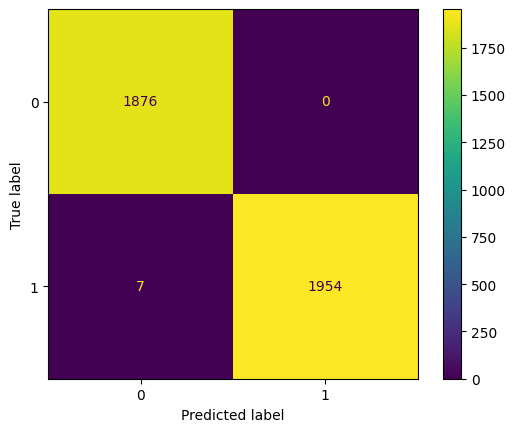

In [39]:
# Create a confusion matrix to visualize the results
log_cm = confusion_matrix(y_val, y_pred)
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=None)
log_disp.plot()
plt.show()

**Notes:** The upper-left quadrant displays true negatives (opinions correctly classified). The upper-right quadrant displays false positives (opinions misclassified as claims). The lower-left quadrant displays false negatives (claims misclassified as opinions). The lower-right quadrant displays true positives (claims correctly classified). This model produces only 7 false negatives and 0 false positives — near-perfect classification.

In [40]:
# Create a classification report
target_labels = ['opinion', 'claim']
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       1.00      1.00      1.00      1876
       claim       1.00      1.00      1.00      1961

    accuracy                           1.00      3837
   macro avg       1.00      1.00      1.00      3837
weighted avg       1.00      1.00      1.00      3837



**Response:** The classification report shows that the random forest model scores were near-perfect across all metrics. The confusion matrix confirms only 7 misclassifications out of 3,837 validation samples.

#### **XGBoost**

Now, evaluate the XGBoost model on the validation set.

In [41]:
# Use the best estimator to predict on the validation data
y_pred = xgb_cv.best_estimator_.predict(X_val_final)

In [42]:
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(3837,))

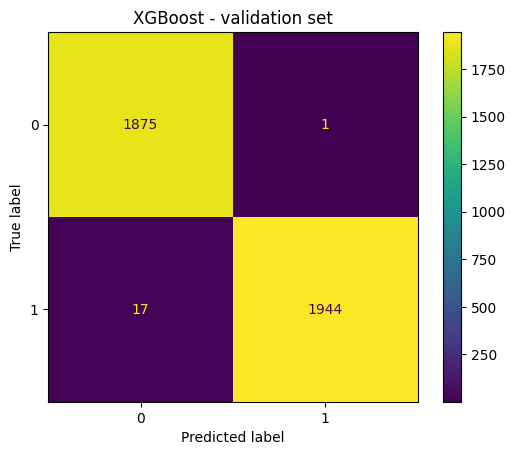

In [43]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_val, y_pred)
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=None)
log_disp.plot()
plt.title('XGBoost - validation set');
plt.show()

In [44]:
# Create a classification report
target_labels = ['opinion', 'claim']
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       0.99      1.00      1.00      1876
       claim       1.00      0.99      1.00      1961

    accuracy                           1.00      3837
   macro avg       1.00      1.00      1.00      3837
weighted avg       1.00      1.00      1.00      3837



**Response:** The results of the XGBoost model were also nearly perfect. However, its errors tended to be false negatives. Identifying claims was the priority, so it's important that the model be good at capturing all actual claim videos. The random forest model has better scores, and is therefore the champion model.

### **Use champion model to predict on test data**

Both random forest and XGBoost architectures resulted in nearly perfect models. Nonetheless, random forest performed slightly better, so it is the champion model.

In [45]:
# Use champion model to predict on test data
y_pred = rf_cv.best_estimator_.predict(X_test_final)

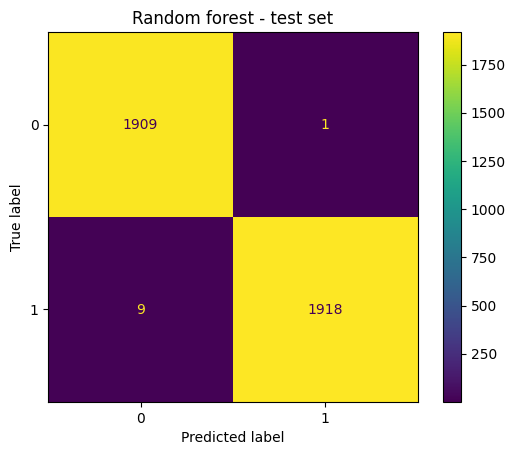

In [46]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_test, y_pred)
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=None)
log_disp.plot()
plt.title('Random forest - test set');
plt.show()

#### **Feature importances of champion model**

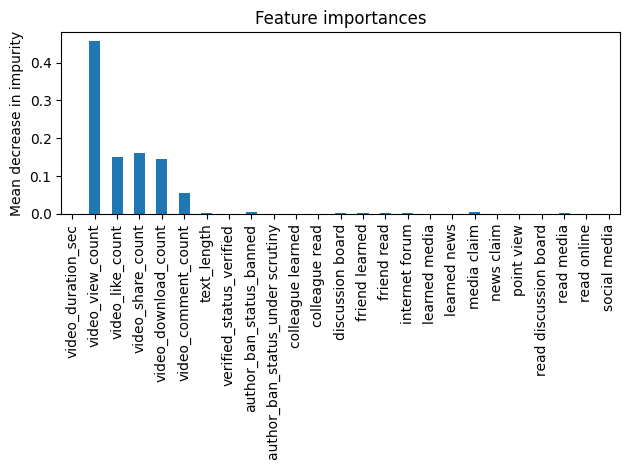

In [47]:
importances = rf_cv.best_estimator_.feature_importances_
rf_importances = pd.Series(importances, index=X_test_final.columns)

fig, ax = plt.subplots()
rf_importances.plot.bar(ax=ax)
ax.set_title('Feature importances')
ax.set_ylabel('Mean decrease in impurity')
fig.tight_layout()

**Response:** The most predictive features were all related to engagement levels generated by the video. This is not unexpected, as analysis from prior EDA pointed to this conclusion. `video_view_count` is the single most important feature (~45.7%), followed by `video_share_count`, `video_like_count`, and `video_download_count`.

### **Conclusion**

1. **Would you recommend using this model? Why or why not?**
Yes, one can recommend this model because it performed exceptionally well on both the validation and test holdout data. The model achieved ~99.5% recall on cross-validation, ~99.8% precision, and near-perfect accuracy on the test set. The model very successfully classified claims and opinions.

2. **What was your model doing? Can you explain how it was making predictions?**
The model's most predictive features were all related to the user engagement levels associated with each video — view count, share count, like count, and download count. It was classifying videos based on how much engagement they received. Claim videos consistently generate higher engagement, so the model learned to use engagement as the primary signal.

3. **Are there new features that you can engineer that might improve model performance?**
Because the model currently performs nearly perfectly, there is no need to engineer any new features.

4. **What features would you want to have that would likely improve the performance of your model?**
The current version of the model does not need any new features. However, it would be helpful to have the number of times the video was reported. It would also be useful to have the total number of user reports for all videos posted by each author.